# 13 — equation-level proxy benchmark（30シナリオ）

## 背景
パラメータを説明するだけでは、制御モデルがどこまで要求wrenchを実現できるか分からない。
そこで、`legged_control` の中心式であるcentroidal dynamics、接触schedule、摩擦制約、
WBCのtorque limit、100 Hz計画を一つの小さな閉ループへまとめ、難易度別30条件を同じ指標で流す。
これは4秒の **equation-level pre-benchmark** であり、repository performanceではない。

## 重要な測定範囲
これは `external/legged_control` のROS node、OCS2 SQP、Pinocchio WBC、Gazebo A1を起動した
end-to-end benchmarkではない。この環境には `roscore`, `roslaunch`, `catkin` が無いためである。
ここで測るのは **上流と同じ物理契約を持つ教育用model-level benchmark**:

- centroidal合力・合moment
- stance/trot接触schedule
- 摩擦pyramid投影
- 33.5 N m torque proxy limit
- 状態noise、policy delay、外乱

したがって、結果は実機歩行性能ではなく、要求wrenchの実現性・tracking・計算時間の比較である。

## 目的
1. 30条件を同一コードで再実行する。
2. tracking、姿勢、高さ、wrench residual、torque飽和、計算時間を保存する。
3. 難しくなるほど、どの制約が先に支配的になるかを分析する。

## 結論の読み方
`pass` はこの縮約modelの閾値を満たした意味だけを持つ。上流repositoryの性能を断定するには、
ROS Noetic + OCS2 + Gazebo環境で同じscenario定義を移植し直す必要がある。


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
print("repository:", ROOT)

import json
import time
import pandas as pd

OUT = ROOT / "notebook_legged" / "assets"
OUT.mkdir(parents=True, exist_ok=True)


repository: /home/takuya/work/mpc_dog


## データの流れ

```text
Scenario
  │ vx_ref, slope, mu, gait, noise, delay, disturbance
  ▼
reference + noisy measured state
  │
  ▼ 100 Hz
centroidal feedback
  │ desired wrench w*=[Fx,Fy,Fz,Mx,My,Mz]
  ▼
contact force allocation
  │ min ||A(contact)F - w*||² + λ||F||²
  ▼
friction/normal-force projection
  │ Fz>=0, |Fx|<=mu Fz, |Fy|<=mu Fz
  ▼
WBC torque proxy
  │ tau_i = J_i^T F_i, |tau|<=33.5 N m
  ▼
delayed plant integration
  │ m vdot = ΣF + mg + disturbance
  │ I ωdot = Σ(r_i×F_i) + disturbance moment
  └──────────── state ───────────→ feedback
```

上流との対応:

- desired wrench / centroidal model → `LeggedRobotDynamicsAD`
- contact schedule → `GaitSchedule`
- force constraint → NMPC `FrictionConeConstraint`
- force allocation → NMPCの現在入力 $u^*[0:12]$ の縮約
- torque proxy → WBCの $M\ddot q-J^TF-S^T\tau+nle=0$ の縮約


## 数式

controller:
\[
F_x^*=m k_v(v_x^{ref}-\hat v_x),\qquad
F_z^*=m[g+k_z(z^{ref}-\hat z)-d_z\hat v_z]
\]
\[
M_{x,y}^*=k_R(R^{ref}_{x,y}-\hat R_{x,y})-d_R\hat\omega_{x,y}
\]

active contactの力を積んだ $F$ に対し、
\[
\min_F \|AF-w^*\|_2^2+\lambda\|F\|_2^2
\]
を解いた後、各足を摩擦pyramidへ投影する。

plant:
\[
\dot v=\frac{1}{m}\left(\sum_iF_i+F_{ext}\right)+g,\qquad
\dot\omega=I^{-1}\left(\sum_i r_i\times F_i+M_{ext}\right).
\]

C++の完全なSQP/WBCを置き換えるものではないが、入力・制約・残差の意味は同じである。


In [2]:
# --- Block A: scenario contract ---
# 内容: 30条件で変える物理量を一つの辞書形式へ揃える。
# 意図: 難易度ごとに別コードを書かず、controllerの性能差だけを比較する。
BASE = dict(
    duration=4.0, dt=0.01, gait="stance", gait_hz=1.35,
    vx_ref=0.0, slope_deg=0.0, mu=0.40, mass_scale=1.0,
    noise_pos=0.0, noise_vel=0.0, delay_ms=0.0,
    force_x=0.0, force_y=0.0, moment_roll=0.0,
)

def scenario(name, level, **changes):
    cfg = BASE | changes
    return {"name": name, "level": level, **cfg}

SCENARIOS = [
    # 簡易: 四脚接地を中心に、単独の小変更だけを加える。
    scenario("E01_static_nominal", "easy"),
    scenario("E02_static_mu050", "easy", mu=0.50),
    scenario("E03_static_mu030", "easy", mu=0.30),
    scenario("E04_forward_010", "easy", vx_ref=0.10),
    scenario("E05_forward_020", "easy", vx_ref=0.20),
    scenario("E06_slope_plus3", "easy", slope_deg=3.0),
    scenario("E07_slope_minus3", "easy", slope_deg=-3.0),
    scenario("E08_mass_plus05", "easy", mass_scale=1.05),
    scenario("E09_noise_small", "easy", noise_pos=0.002, noise_vel=0.01),
    scenario("E10_push_5N", "easy", force_x=5.0),

    # 普通: trot、速度、斜面、noise、delayを現実的範囲で一つまたは二つ組み合わせる。
    scenario("N01_trot_static", "normal", gait="trot"),
    scenario("N02_trot_v020", "normal", gait="trot", vx_ref=0.20),
    scenario("N03_trot_v040", "normal", gait="trot", vx_ref=0.40),
    scenario("N04_trot_slope5", "normal", gait="trot", slope_deg=5.0),
    scenario("N05_trot_mu030", "normal", gait="trot", mu=0.30),
    scenario("N06_trot_mass115", "normal", gait="trot", mass_scale=1.15),
    scenario("N07_trot_noise", "normal", gait="trot", noise_pos=0.005, noise_vel=0.03),
    scenario("N08_trot_delay10", "normal", gait="trot", delay_ms=10.0),
    scenario("N09_trot_push15", "normal", gait="trot", force_y=15.0),
    scenario("N10_v040_slope5", "normal", gait="trot", vx_ref=0.40, slope_deg=5.0),

    # 高難度: 低摩擦・大速度・大外乱・大delayを組み合わせ、制約支配を観察する。
    scenario("H01_v080", "hard", gait="trot", vx_ref=0.80),
    scenario("H02_mu018", "hard", gait="trot", vx_ref=0.40, mu=0.18),
    scenario("H03_slope12", "hard", gait="trot", vx_ref=0.30, slope_deg=12.0),
    scenario("H04_mass140", "hard", gait="trot", mass_scale=1.40),
    scenario("H05_delay30", "hard", gait="trot", vx_ref=0.50, delay_ms=30.0),
    scenario("H06_noise_large", "hard", gait="trot", vx_ref=0.40, noise_pos=0.02, noise_vel=0.12),
    scenario("H07_push40", "hard", gait="trot", vx_ref=0.30, force_y=40.0),
    scenario("H08_roll12Nm", "hard", gait="trot", moment_roll=12.0),
    scenario("H09_combo_lowmu_slope", "hard", gait="trot", vx_ref=0.60, mu=0.20, slope_deg=10.0),
    scenario("H10_combo_all", "hard", gait="trot", vx_ref=0.70, mu=0.18, slope_deg=12.0,
             mass_scale=1.25, delay_ms=30.0, noise_pos=0.02, noise_vel=0.12,
             force_y=30.0, moment_roll=8.0),
]

assert len(SCENARIOS) == 30
pd.DataFrame(SCENARIOS).groupby("level").size()


level
easy      10
hard      10
normal    10
dtype: int64

In [3]:
# --- Block B: gait / contact schedule ---
# 数式: trotは対角2脚が半周期ごとに交代する。
# C++対応: GaitScheduleが返すcontactFlags(t)。NMPCがmodeを最適化するのではない。
LEG_NAMES = ("LF", "RF", "LH", "RH")
FOOT_POS = np.array([
    [ 0.25,  0.15, -0.30],
    [ 0.25, -0.15, -0.30],
    [-0.25,  0.15, -0.30],
    [-0.25, -0.15, -0.30],
])

def contact_flags(t, gait, gait_hz):
    if gait == "stance":
        return np.ones(4, dtype=bool)
    phase = (t * gait_hz) % 1.0
    return np.array([1, 0, 0, 1], dtype=bool) if phase < 0.5 else np.array([0, 1, 1, 0], dtype=bool)

# --- Block C: wrench matrix A ---
# 各足力Fiは合力へI3、CoM momentへskew(ri)で寄与する: [ΣFi; Σri×Fi] = A F。
def skew(r):
    x, y, z = r
    return np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]])

def wrench_matrix(active):
    blocks_force = [np.eye(3) for _ in active]
    blocks_moment = [skew(FOOT_POS[i]) for i in active]
    return np.vstack([np.hstack(blocks_force), np.hstack(blocks_moment)])

print("all stance A:", wrench_matrix(np.arange(4)).shape)
print("trot A:", wrench_matrix(np.array([0, 3])).shape)


all stance A: (6, 12)
trot A: (6, 6)


In [4]:
# --- Block D: force allocator + friction projection ---
# 数式: min ||AF-w||² + ridge||F||²。
# コメント: pseudoinverseでunconstrained解を得てから、各足をWBC型摩擦pyramidへ投影する。
# 注意: 上流NMPCのsoft円錐とqpOASESの厳密QPを再現するsolverではない。
def project_foot_force(f, mu, fz_max):
    fx, fy, fz = f
    fz = np.clip(fz, 0.0, fz_max)
    fx = np.clip(fx, -mu*fz, mu*fz)
    fy = np.clip(fy, -mu*fz, mu*fz)
    return np.array([fx, fy, fz])

def allocate_forces(wrench_des, contact, mu, mass):
    active = np.flatnonzero(contact)
    A = wrench_matrix(active)
    ridge = 1e-5
    # 正規方程式ではなくlstsqで解き、rank不足のtrotでも最小norm解を得る。
    A_aug = np.vstack([A, np.sqrt(ridge)*np.eye(3*len(active))])
    b_aug = np.r_[wrench_des, np.zeros(3*len(active))]
    f_active = np.linalg.lstsq(A_aug, b_aug, rcond=None)[0].reshape(-1, 3)
    fz_max = 3.0 * mass * 9.81 / max(len(active), 1)
    f_active = np.array([project_foot_force(f, mu, fz_max) for f in f_active])
    forces = np.zeros((4, 3))
    forces[active] = f_active
    realized = A @ f_active.ravel()
    residual = np.linalg.norm(realized - wrench_des) / max(np.linalg.norm(wrench_des), 1.0)
    margin = np.min(mu*f_active[:,2] - np.max(np.abs(f_active[:,:2]), axis=1))
    return forces, realized, residual, margin

# --- Block E: WBC torque proxy ---
# 数式: tau≈J^T F。A1の脚長に近いlever armで3関節torqueを近似する。
# 上流WBCは42変数QPなので、このproxyはtorque飽和傾向だけを見る。
J_PROXY = np.array([[0.08, 0.00, 0.00],
                    [0.00, 0.20, 0.10],
                    [0.00, 0.10, 0.20]])
TAU_LIMIT = 33.5

def torque_proxy(forces):
    tau = np.array([J_PROXY.T @ f for f in forces])
    saturation = np.mean(np.abs(tau) >= TAU_LIMIT)
    return np.clip(tau, -TAU_LIMIT, TAU_LIMIT), saturation


In [5]:
# --- Block F: closed-loop simulation ---
# 処理順: noisy state→100 Hz controller→force allocation→delay→plant integration。
# 出力: tracking、姿勢、高さ、制約、torque、計算時間をscenarioごとに集約する。
def run_scenario(cfg, seed=42):
    rng = np.random.default_rng(seed)
    dt = cfg["dt"]
    steps = int(cfg["duration"] / dt)
    mass = 12.5 * cfg["mass_scale"]
    inertia = np.array([0.24, 0.55, 0.65]) * cfg["mass_scale"]
    slope = np.deg2rad(cfg["slope_deg"])
    delay_steps = int(round(cfg["delay_ms"] / 1000 / dt))

    # state = [z, vx, vy, vz, roll, pitch, wx, wy]
    state = np.array([0.30, 0.0, 0.0, 0.0, 0.0, slope, 0.0, 0.0])
    force_queue = [np.zeros((4, 3)) for _ in range(delay_steps + 1)]
    command_forces = np.zeros((4, 3))
    controller_times, logs = [], []
    residuals, margins, tau_sats = [], [], []

    for k in range(steps):
        t = k * dt
        contact = contact_flags(t, cfg["gait"], cfg["gait_hz"])
        measured = state.copy()
        measured[0] += rng.normal(0, cfg["noise_pos"])
        measured[1:4] += rng.normal(0, cfg["noise_vel"], 3)

        # 上流と同じ100 Hzで計画を更新し、間のplant stepでは直前commandを使う。
        if k % max(1, int(round(0.01/dt))) == 0:
            tic = time.perf_counter()
            z, vx, vy, vz, roll, pitch, wx, wy = measured
            ax_des = 2.0 * (cfg["vx_ref"] - vx)
            ay_des = -2.0 * vy
            az_des = 35.0 * (0.30 - z) - 9.0 * vz
            mx_des = 18.0 * (0.0 - roll) - 3.0 * wx
            my_des = 18.0 * (slope - pitch) - 3.0 * wy
            wrench_des = np.array([
                mass*ax_des, mass*ay_des, mass*(9.81 + az_des),
                mx_des, my_des, 0.0,
            ])
            command_forces, realized, residual, margin = allocate_forces(
                wrench_des, contact, cfg["mu"], mass
            )
            _, tau_sat = torque_proxy(command_forces)
            controller_times.append(time.perf_counter() - tic)
            residuals.append(residual); margins.append(margin); tau_sats.append(tau_sat)

        force_queue.append(command_forces.copy())
        applied = force_queue.pop(0)
        # slope座標の縮約: 重力を斜面接線(-x)と法線(-z)へ分解する。
        # 完全な3D接触frame回転ではないが、slopeを無意味なラベルにしない。
        gravity_on_slope = np.array([-mass*9.81*np.sin(slope), 0.0, -mass*9.81*np.cos(slope)])
        net_force = applied.sum(axis=0) + gravity_on_slope + np.array([cfg["force_x"], cfg["force_y"], 0.0])
        net_moment = np.cross(FOOT_POS, applied).sum(axis=0) + np.array([cfg["moment_roll"], 0.0, 0.0])

        acc = net_force / mass
        alpha = net_moment[:2] / inertia[:2]
        state[1:4] += dt * acc
        state[0] += dt * state[3]
        state[6:8] += dt * alpha
        state[4:6] += dt * state[6:8]
        logs.append(state.copy())

    h = np.asarray(logs)
    z_rmse = float(np.sqrt(np.mean((h[:,0]-0.30)**2)))
    vx_rmse = float(np.sqrt(np.mean((h[:,1]-cfg["vx_ref"])**2)))
    angle_rmse = float(np.sqrt(np.mean(h[:,4]**2 + (h[:,5]-slope)**2)))
    fallen = bool(np.any(h[:,0] < 0.16) or np.any(np.abs(h[:,4:6]) > 0.75))
    mean_residual = float(np.mean(residuals))
    sat_rate = float(np.mean(tau_sats))
    solve_ms = np.asarray(controller_times) * 1e3
    score = np.clip(100 - 180*z_rmse - 35*vx_rmse - 55*angle_rmse
                    - 45*mean_residual - 100*sat_rate - 100*fallen, 0, 100)
    passed = (not fallen and z_rmse < 0.10 and vx_rmse < 0.40
              and angle_rmse < 0.30 and mean_residual < 0.55 and sat_rate < 0.25)
    return {
        "name": cfg["name"], "level": cfg["level"], "pass": bool(passed),
        "score": float(score), "z_rmse_m": z_rmse, "vx_rmse_mps": vx_rmse,
        "angle_rmse_rad": angle_rmse, "wrench_residual": mean_residual,
        "min_friction_margin_N": float(np.min(margins)),
        "torque_sat_rate": sat_rate, "fallen": fallen,
        "controller_mean_ms": float(np.mean(solve_ms)),
        "controller_p95_ms": float(np.percentile(solve_ms, 95)),
        "realtime_margin_at_100Hz": float(10.0 / max(np.percentile(solve_ms,95), 1e-9)),
    }


In [6]:
# --- Block G: 30 scenariosを実行して保存 ---
# 意図: 同じseed・同じmetricで難易度間を比較し、都合の良いrunだけを選ばない。
started = time.perf_counter()
results = [run_scenario(cfg, seed=1000+i) for i, cfg in enumerate(SCENARIOS)]
elapsed = time.perf_counter() - started
df = pd.DataFrame(results)

csv_path = OUT / "legged_model_benchmark_30.csv"
json_path = OUT / "legged_model_benchmark_30.json"
df.to_csv(csv_path, index=False)
json_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"30 scenarios wall time: {elapsed:.3f} s")
display(df)
display(df.groupby("level").agg(
    scenarios=("name","count"),
    passed=("pass","sum"),
    mean_score=("score","mean"),
    mean_vx_rmse=("vx_rmse_mps","mean"),
    mean_wrench_residual=("wrench_residual","mean"),
    p95_controller_ms=("controller_p95_ms","max"),
))


30 scenarios wall time: 1.902 s


,name,level,pass,score,z_rmse_m,vx_rmse_mps,angle_rmse_rad,wrench_residual,min_friction_margin_N,torque_sat_rate,fallen,controller_mean_ms,controller_p95_ms,realtime_margin_at_100Hz
0,E01_static_nominal,easy,True,99.640163,0.001998,2.117839e-16,3.873128e-16,0.000002,12.190521,0.000000,False,0.141893,0.215003,46.511002
1,E02_static_mu050,easy,True,99.640163,0.001998,2.117839e-16,3.873128e-16,0.000002,15.238152,0.000000,False,0.128143,0.136127,73.460973
2,E03_static_mu030,easy,True,99.640163,0.001998,2.117839e-16,3.873128e-16,0.000002,9.142891,0.000000,False,0.128074,0.135405,73.852416
3,E04_forward_010,easy,True,98.769299,0.001998,2.488118e-02,4.126726e-07,0.000003,11.337487,0.000000,False,0.127884,0.135020,74.063160
4,E05_forward_020,easy,True,97.898435,0.001998,4.976237e-02,8.253451e-07,0.000003,10.412505,0.000000,False,0.127147,0.133199,75.075889
5,E06_slope_plus3,easy,True,91.512796,0.001963,2.323849e-01,3.787661e-06,0.000003,9.871780,0.000000,False,0.127259,0.133914,74.674513
6,E07_slope_minus3,easy,True,91.512796,0.001963,2.323849e-01,3.787661e-06,0.000003,9.871780,0.000000,False,0.127080,0.132981,75.198695
7,E08_mass_plus05,easy,True,99.640163,0.001998,3.807150e-16,5.970959e-16,0.000002,12.800048,0.000000,False,0.128187,0.134121,74.559479
8,E09_noise_small,easy,True,99.652492,0.001777,7.885517e-04,6.231373e-08,0.000003,11.546117,0.000000,False,0.159993,0.241108,41.475160
9,E10_push_5N,easy,True,93.303245,0.001998,1.810501e-01,2.950950e-06,0.000003,10.412993,0.000000,False,0.133555,0.154111,64.888092


,scenarios,passed,mean_score,mean_vx_rmse,mean_wrench_residual,p95_controller_ms
level,,,,,,
easy,10,10,97.120971,0.072125,0.000003,0.241108
hard,10,5,55.091435,0.412877,0.093647,0.325192
normal,10,8,90.123866,0.100346,0.015335,0.146654


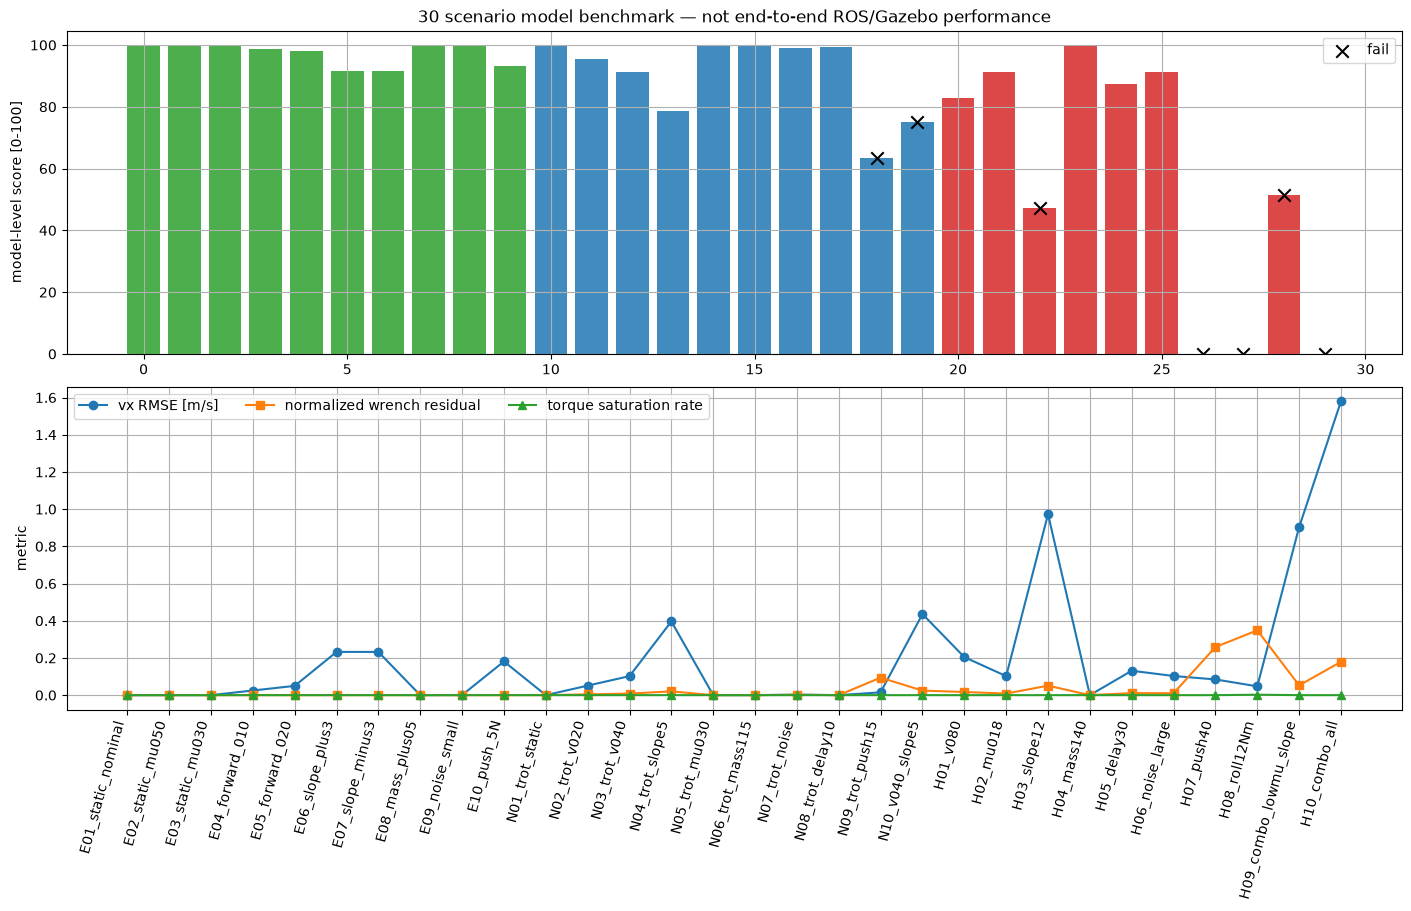

/home/takuya/work/mpc_dog/notebook_legged/assets/legged_model_benchmark_30.png


In [7]:
# --- Block H: 性能図 ---
# 上: score。下: 主要制約metric。色は難易度、×はfail。
colors = {"easy":"tab:green", "normal":"tab:blue", "hard":"tab:red"}
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
x = np.arange(len(df))
bar_colors = [colors[v] for v in df["level"]]
axes[0].bar(x, df["score"], color=bar_colors, alpha=0.85)
axes[0].scatter(x[~df["pass"]], df.loc[~df["pass"],"score"], marker="x", s=80, color="black", label="fail")
axes[0].set_ylabel("model-level score [0-100]")
axes[0].set_title("30 scenario model benchmark — not end-to-end ROS/Gazebo performance")
axes[0].legend()

axes[1].plot(x, df["vx_rmse_mps"], "o-", label="vx RMSE [m/s]")
axes[1].plot(x, df["wrench_residual"], "s-", label="normalized wrench residual")
axes[1].plot(x, df["torque_sat_rate"], "^-", label="torque saturation rate")
axes[1].set_ylabel("metric")
axes[1].legend(ncol=3)
axes[1].set_xticks(x, df["name"], rotation=75, ha="right")
fig_path = OUT / "legged_model_benchmark_30.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(fig_path)


## 結果の分析方法
次の順で失敗原因を読む。

1. `fallen`: 縮約plantが高さ/姿勢限界を超えた。
2. `wrench_residual`: 接触幾何と摩擦で要求wrenchを作れない。
3. `min_friction_margin_N`: 0付近は摩擦境界がactive。
4. `torque_sat_rate`: forceは作れても関節torque proxyで飽和。
5. `controller_p95_ms`: 100 Hzの10 ms deadlineに対する計算余裕。

## この先の本当のrepository benchmark
同じ30 scenario schemaを次のROS/Gazebo項目へ移植する。

- `task.info`, `reference.info`, `gait.info` をscenarioごとに生成
- `/cmd_vel` とgait commandをtimestamp付きpublish
- `/legged_robot_mpc_observation`, odometry, joint state, WBC/solver統計をrosbag保存
- 同じRMSE、転倒、constraint、torque、deadline指標を計算
- A1 URDF、Gazebo contact、OCS2/qpOASESを含む結果だけを上流end-to-end性能と呼ぶ

現環境ではROS/OCS2が無いため、そこを実行済みと偽らない。
実際のA1 MuJoCo plant、20秒以上のGIF、物理閾値を使う実行証拠は
`14_a1_mujoco_benchmark_30_scenarios.ipynb` へ進む。
